# Life Expectancy Prediction using Machine Learning

This project analyzes socio-economic and health factors affecting life expectancy and builds predictive models to estimate life expectancy across countries.


## Problem Statement

Life expectancy varies significantly across countries due to socio-economic, healthcare, and demographic factors.

This project aims to:

1. Identify the key factors influencing life expectancy.
2. Analyze the relationship between health expenditure, disease burden, and economic development.
3. Build machine learning models to accurately predict life expectancy.
4. Compare different regression models to determine the best performing approach.


## Imported libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor


## Loaded Dataset

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Basic information

In [3]:
df.shape


(2938, 22)

In [4]:
df.columns = df.columns.str.strip()
df.columns


Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [5]:
df.isnull().sum()



Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

## Data Cleaning

In [6]:
# GDP
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
df['log_GDP'] = np.log1p(df['GDP'])

# Population
df['Population'] = df['Population'].fillna(df['Population'].median())
df['log_Population'] = np.log1p(df['Population'])

# Immunization
df['Hepatitis B'] = df['Hepatitis B'].fillna(df['Hepatitis B'].mean())
df['Polio'] = df['Polio'].fillna(df['Polio'].mean())
df['Diphtheria'] = df['Diphtheria'].fillna(df['Diphtheria'].mean())

# Alcohol
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].median())

# Total expenditure
df['Total expenditure'] = df['Total expenditure'].fillna(df['Total expenditure'].median())

# BMI & Thinness
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['thinness  1-19 years'] = df['thinness  1-19 years'].fillna(df['thinness  1-19 years'].mean())
df['thinness 5-9 years'] = df['thinness 5-9 years'].fillna(df['thinness 5-9 years'].mean())

# Income + Schooling
df['Income composition of resources'] = df['Income composition of resources'].fillna(df['Income composition of resources'].mean())
df['Schooling'] = df['Schooling'].fillna(df['Schooling'].mean())



In [7]:
df.isnull().sum()


Country                             0
Year                                0
Status                              0
Life expectancy                    10
Adult Mortality                    10
infant deaths                       0
Alcohol                             0
percentage expenditure              0
Hepatitis B                         0
Measles                             0
BMI                                 0
under-five deaths                   0
Polio                               0
Total expenditure                   0
Diphtheria                          0
HIV/AIDS                            0
GDP                                 0
Population                          0
thinness  1-19 years                0
thinness 5-9 years                  0
Income composition of resources     0
Schooling                           0
log_GDP                             0
log_Population                      0
dtype: int64

In [8]:
df = df.dropna()


In [9]:
df.isnull().sum()



Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
log_GDP                            0
log_Population                     0
dtype: int64

In [10]:
df.shape

(2928, 24)

## Feature Engineering

In [11]:
df['Immunization_Score'] = (
    df['Polio'] +
    df['Hepatitis B'] +
    df['Diphtheria']
) / 3


In [12]:
df['Mortality_Index'] = (
    df['Adult Mortality'] +
    df['infant deaths'] +
    df['under-five deaths']
) / 3


In [13]:
df['Health_Investment_Ratio'] = (
    df['Total expenditure'] / df['GDP']
)


In [14]:
df[['Immunization_Score','Mortality_Index','Health_Investment_Ratio']].head()


,Immunization_Score,Mortality_Index,Health_Investment_Ratio
0,45.333333,136.000000,0.013966
1,60.666667,140.333333,0.013351
2,63.333333,141.000000,0.012869
3,67.000000,144.666667,0.012717
4,68.000000,147.666667,0.123864


Immunization_Score represents overall vaccination coverage.

Mortality_Index captures overall mortality burden.

Health_Investment_Ratio measures relative health spending efficiency.

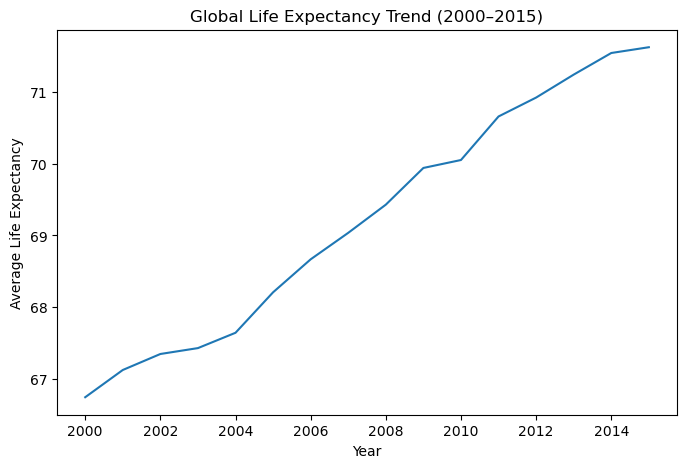

In [15]:
avg_life = df.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_life.index, avg_life.values)
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.title("Global Life Expectancy Trend (2000–2015)")
plt.show()


Insight : Global life expectancy shows a steady upward trend between 2000 and 2015, indicating improvements in healthcare systems and socio-economic conditions worldwide.

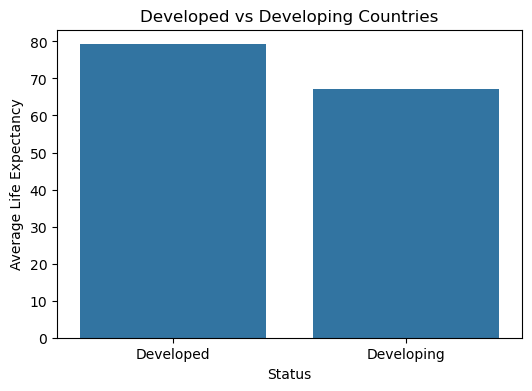

In [16]:
status_avg = df.groupby('Status')['Life expectancy'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=status_avg.index, y=status_avg.values)
plt.ylabel("Average Life Expectancy")
plt.title("Developed vs Developing Countries")
plt.show()


Insight : Developed countries consistently maintain significantly higher life expectancy compared to developing countries.

## EDA

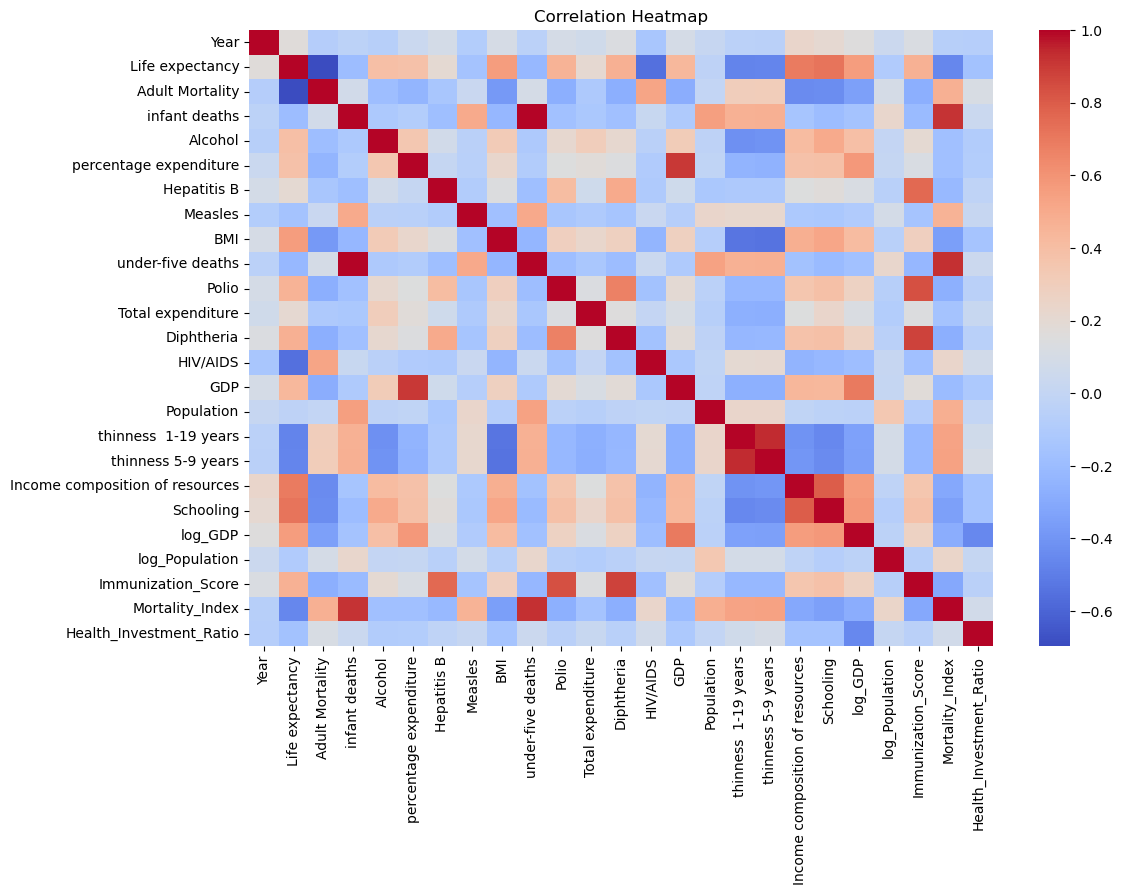

In [17]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


The correlation analysis reveals that Schooling and Income composition 
are the strongest positive predictors of Life expectancy.

Mortality_Index shows a strong negative relationship, indicating 
reducing mortality burden is critical for lifespan improvement.

Interestingly, GDP has moderate correlation, suggesting that 
economic growth alone is not sufficient without educational and 
health improvements.

## Model Preparation

In [18]:
# Drop unnecessary columns
df_model = df.drop(columns=['Country'])

# One-hot encode Status
df_model = pd.get_dummies(df_model, columns=['Status'], drop_first=True)

# Define X and y
X = df_model.drop(columns=['Life expectancy'])
y = df_model['Life expectancy']


In [19]:
X.shape


(2928, 25)

## Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (2342, 25)
X_test: (586, 25)


## Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression R2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression R2: 0.8199496394839121
Linear Regression RMSE: 3.9464222496617336


## Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest R2: 0.9680629117340861
Random Forest RMSE: 1.6620887602436636


## XGBoost

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost R2:", r2_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost R2: 0.9592747949089722
XGBoost RMSE: 1.876887290127618


## Model Comparison Table

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2 Score": [r2_lr, r2_rf, r2_xgb],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,0.819950,3.946422
1,Random Forest,0.968063,1.662089
2,XGBoost,0.959275,1.876887


### Among all models tested, Random Forest achieved the highest performance with an R² score of 0.968 and lowest RMSE, indicating strong predictive capability for life expectancy based on socio-economic and health indicators.

## Feature Importance Plot

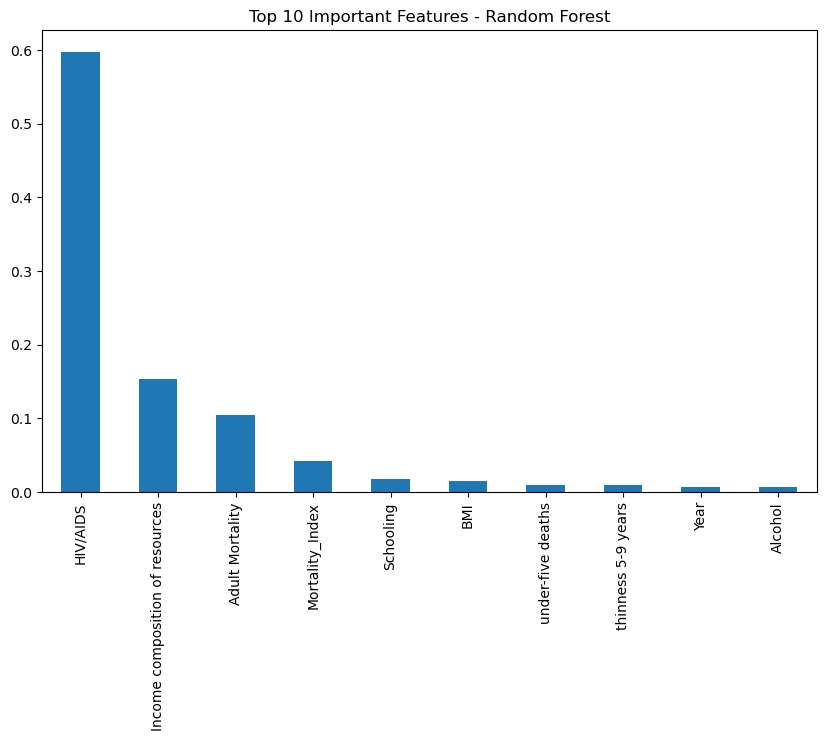

In [25]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features - Random Forest")
plt.show()


Feature importance analysis revealed that HIV/AIDS prevalence is the strongest predictor of life expectancy, followed by income composition of resources and adult mortality. This indicates that disease burden and socio-economic development significantly influence national life expectancy trends.

## Residual & Actual vs Predicted Plot

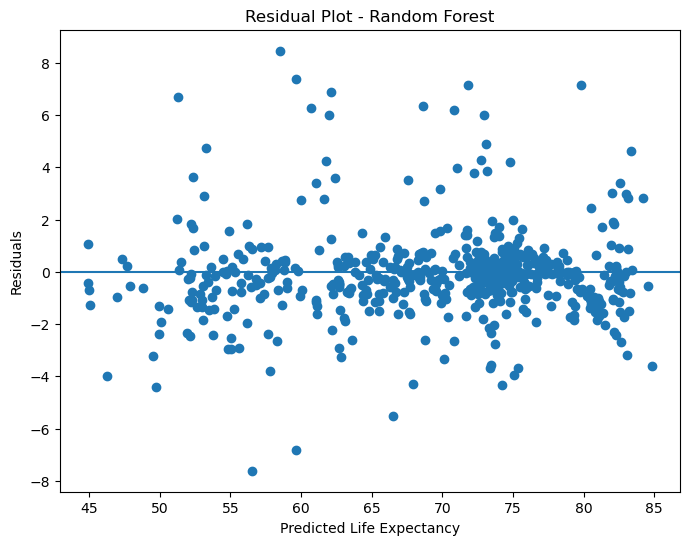

In [26]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()


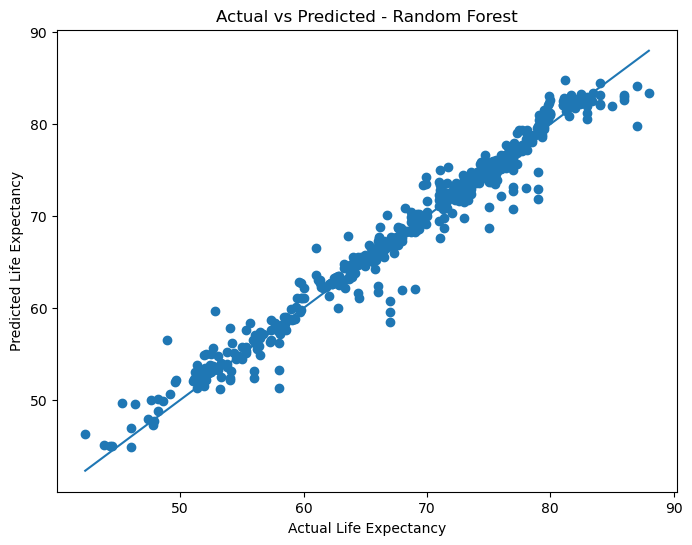

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted - Random Forest")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# Conclusion :

This project aimed to analyze and predict life expectancy using socio-economic and health-related indicators.

After performing data cleaning, feature engineering, and model comparison:

Linear Regression achieved an R² score of 0.82

Random Forest achieved the best performance with R² = 0.968

XGBoost achieved R² = 0.959

Random Forest was selected as the final model due to its superior predictive performance and lower RMSE.

Feature importance analysis revealed that:

HIV/AIDS prevalence is the strongest predictor of life expectancy.

Income composition of resources significantly influences outcomes.

Adult mortality also plays a major role.

This indicates that disease burden and socio-economic development are critical determinants of life expectancy across countries.